In [2]:
# I think this is everything we used on HW  + HW 1 + HW 2
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas
import pyproj
import rasterio
import rasterstats
import json
from rasterio.mask import mask
from rasterio.plot import show
import matplotlib.colors as pltc
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
from sklearn.feature_extraction.text import CountVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
import string
from nltk.corpus import stopwords
import string
import emoji
from datetime import timedelta


In [3]:
data_dir= "C:/Users/np37/Box/Data Science Project/"


I will start with some exploration of the data, just to check everything is in order.

In [4]:
df = pd.read_csv(data_dir + "merged_airbnb.csv")
df.head(5)

,id,geometry,region,distance_to_wall_m,borough,listing_url,scrape_id,last_scraped,source,name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,Pankow,https://www.airbnb.com/rooms/3176,2.024122e+13,2024-12-21,city scrape,Fabulous Flat in great Location,...,4.69,4.92,4.62,First name and Last name: Nicolas Krotz <br/> ...,f,1.0,1.0,0.0,0.0,0.78
1,9991,POINT (13.41805 52.53269),East Berlin,1291.171194,Pankow,https://www.airbnb.com/rooms/9991,2.024122e+13,2024-12-21,city scrape,Geourgeous flat - outstanding views,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1.0,1.0,0.0,0.0,0.06
2,14325,POINT (13.40366 52.54813),East Berlin,260.201295,Pankow,https://www.airbnb.com/rooms/14325,2.024122e+13,2024-12-21,city scrape,Studio Apartment in Prenzlauer Berg,...,4.85,4.60,4.45,NaN,f,4.0,4.0,0.0,0.0,0.15
3,16644,POINT (13.43508 52.50312),West Berlin,357.694043,Friedrichshain-Kreuzberg,https://www.airbnb.com/rooms/16644,2.024122e+13,2024-12-21,city scrape,In the Heart of Berlin - Kreuzberg,...,4.86,4.67,4.71,NaN,f,2.0,2.0,0.0,0.0,0.27
4,17904,POINT (13.42166 52.49419),West Berlin,1142.908319,Neukölln,https://www.airbnb.com/rooms/17904,2.024122e+13,2024-12-21,city scrape,Beautiful Kreuzberg studio - 3 months minimum,...,4.92,4.87,4.65,NaN,f,1.0,1.0,0.0,0.0,1.65


In [6]:
# I know there are some repeated lines, so let's get rid of them get a dataset with no duplicates

# Get the number of rows before dropping duplicates
initial_count = len(df)

# Drop the exact duplicates
df_idunique = df.drop_duplicates()
# Get the number of rows after dropping duplicates
final_count = len(df_idunique)
# Calculate how many rows were dropped
dropped_count = initial_count - final_count
print(f"Number of observations dropped: {dropped_count}")
print(f"Remaining observations: {final_count}")


Number of observations dropped: 37837
Remaining observations: 17285


In [7]:
# Group by 'id' and check for columns where the values are NOT repeated (i.e., have more than 1 unique value per id)
non_repeating_columns = []

for column in df_idunique.columns:
    # Skip 'id' as it will always repeat
    if column == 'id':
        continue
    
    # Check if there is more than 1 unique value for each 'id' in this column
    if df_idunique.groupby('id')[column].nunique().gt(1).any():
        non_repeating_columns.append(column)

print(f"Columns where values are not repeated for repeated IDs: {non_repeating_columns}")

Columns where values are not repeated for repeated IDs: ['geometry', 'region', 'distance_to_wall_m', 'borough']


So ID's are not necessarily unique. They might refer to a different building in a different borough. That's fine, I think as long as we don't have exact replicates, we're working with the right subset of observations.

Let's see how many observations we have on each side of the wall.

In [8]:
print(df_idunique['region'].value_counts())

region
West Berlin    9341
East Berlin    7932
Unknown          12
Name: count, dtype: int64


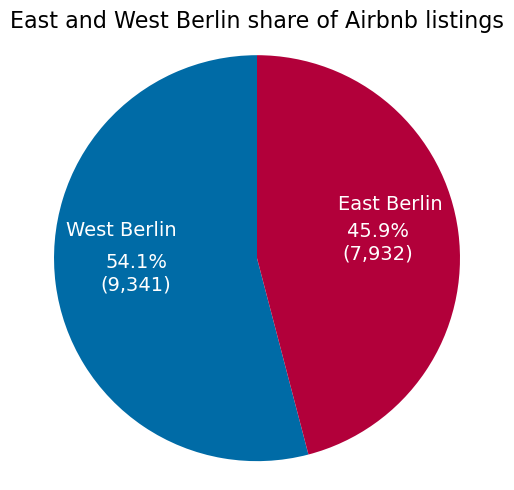

In [9]:
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin']) &
    df_idunique['borough'].notnull()
]

# Count observations by region
region_counts = df_filtered['region'].value_counts()

# Define colors: East = cranberry red, West = Economist blue
colors = ['#B2003A', '#006BA6'] if 'East Berlin' in region_counts.index[0] else ['#006BA6', '#B2003A']

# Custom label function
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count:,})'
    return my_autopct

# Plot pie chart
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct=make_autopct(region_counts),
    colors=colors,
    startangle=90,
    textprops={'color': 'white',  'fontsize': 14},  # Make the text white
    labeldistance=0.4  # Place the labels inside the pie
)

# Adding the labels manually inside the pie because I don't know a better way.
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2  # Middle angle of the wedge
    x = 0.4 * wedge.r * np.cos(np.radians(angle))  # X position inside the pie
    y = 0.5 * wedge.r * np.sin(np.radians(angle))  # Y position inside the pie
    y += 0.2  # Move the labels higher (adjust as needed)
    texts[i].set_position((x, y))  # Move the label to the new position

# Customize font size
plt.title('East and West Berlin share of Airbnb listings', fontsize=16, color='black')  # Title in black
plt.axis('equal')
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(data_dir + "Figures/Number_listings.png", dpi=300)

# Show the plot
plt.show()


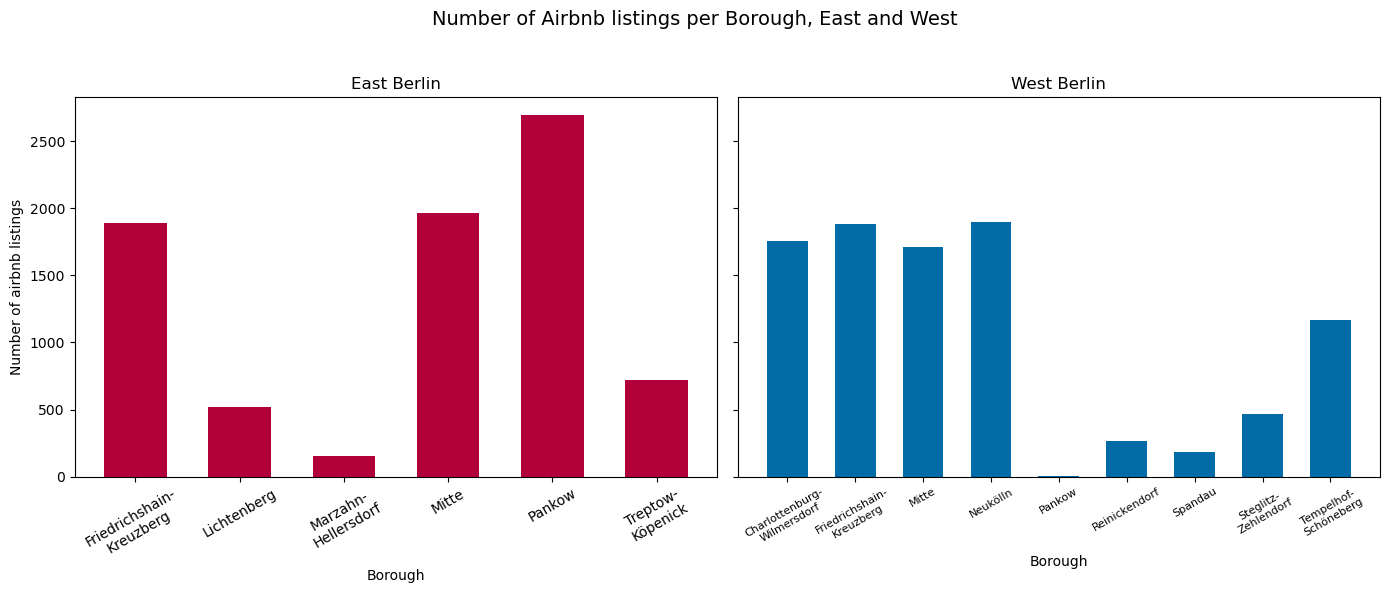

In [13]:
# Filter data to keep only East and West Berlin with non-null boroughs
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin']) &
    df_idunique['borough'].notnull()
]

# Group by borough and region, counting the number of observations
grouped = df_filtered.groupby(['borough', 'region']).size().reset_index(name='count')

# Separate data for East and West Berlin
east = grouped[grouped['region'] == 'East Berlin'].copy()
west = grouped[grouped['region'] == 'West Berlin'].copy()

# Format borough labels (keep hyphen and insert newline after it)
east['formatted_borough'] = east['borough'].apply(lambda x: x.replace('-', '-\n'))
west['formatted_borough'] = west['borough'].apply(lambda x: x.replace('-', '-\n'))

# Custom color palette
cranberry_red = '#B2003A'
economist_blue = '#006BA6'

# Set consistent bar width and x positions
bar_width = 0.6
east_x = np.arange(len(east))
west_x = np.arange(len(west))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# East Berlin subplot
axes[0].bar(east_x, east['count'], width=bar_width, color=cranberry_red)
axes[0].set_xticks(east_x)
axes[0].set_xticklabels(east['formatted_borough'], rotation=30, fontsize=10)
axes[0].set_title('East Berlin')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Number of airbnb listings')

# West Berlin subplot
axes[1].bar(west_x, west['count'], width=bar_width, color=economist_blue)
axes[1].set_xticks(west_x)
axes[1].set_xticklabels(west['formatted_borough'], rotation=30, fontsize=8)
axes[1].set_title('West Berlin')
axes[1].set_xlabel('Borough')

plt.suptitle('Number of Airbnb listings per Borough, East and West', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(data_dir + "Figures/Number_listings_perborough.png", dpi=300)
plt.show()

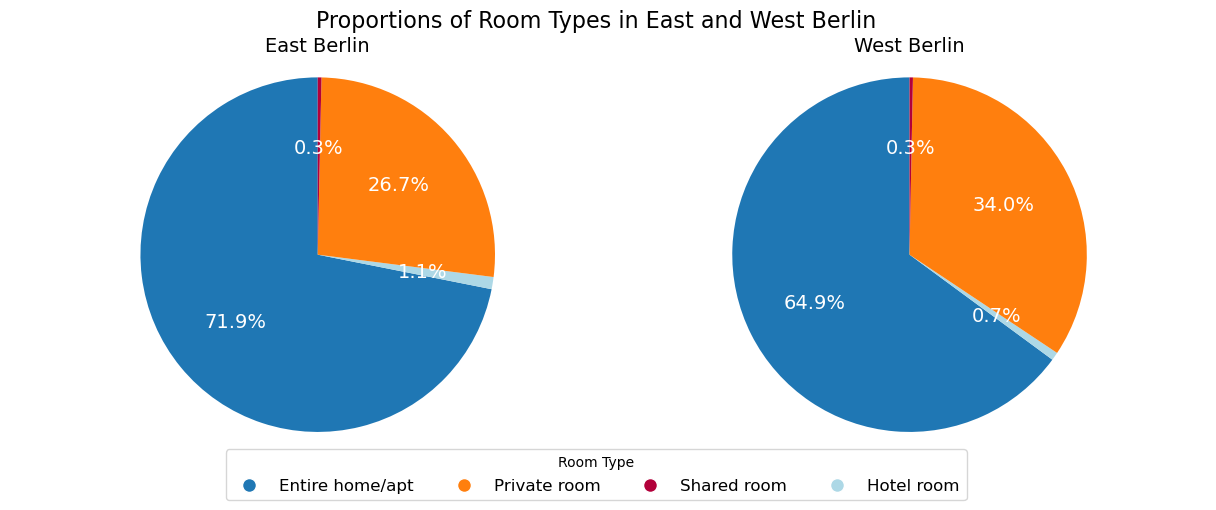

In [38]:
# Filter data to keep only East and West Berlin with non-null room_type
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin']) &
    df_idunique['room_type'].notnull()
]

# Group by region and room_type, counting the number of observations
grouped = df_filtered.groupby(['region', 'room_type']).size().reset_index(name='count')

# Separate data for East and West Berlin
east = grouped[grouped['region'] == 'East Berlin']
west = grouped[grouped['region'] == 'West Berlin']

# Use colorblind-friendly colors
room_type_colors = {
    'Entire home/apt': '#1f77b4',  # Blue
    'Private room': '#ff7f0e',     # Orange
    'Shared room': '#B2003A',      # Red 
    'Hotel room': '#ADD8E6'        # Light blue
}

# Plot pie charts for East and West Berlin
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# East Berlin pie chart
wedges_east, _, _ = axes[0].pie(
    east['count'],
    labels=east['room_type'],
    autopct='%1.1f%%',  # Directly show percentage
    colors=[room_type_colors.get(rt, '#D3D3D3') for rt in east['room_type']],  # Default gray if unknown room_type
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[0].set_title('East Berlin', fontsize=14)
axes[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# West Berlin pie chart
wedges_west, _, _ = axes[1].pie(
    west['count'],
    labels=west['room_type'],
    autopct='%1.1f%%',  # Directly show percentage
    colors=[room_type_colors.get(rt, '#D3D3D3') for rt in west['room_type']],  # Default gray if unknown room_type
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[1].set_title('West Berlin', fontsize=14)
axes[1].axis('equal')

# Add the legend below the pie charts
labels = list(room_type_colors.keys())
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=room_type_colors[lt], markersize=10) for lt in labels]

# Set the legend location to a more controlled place
fig.legend(handles, labels, title="Room Type", loc='center', fontsize=12, bbox_to_anchor=(0.5, 0.05), ncol=4)

# Overall title and layout
plt.suptitle('Proportions of Room Types in East and West Berlin', fontsize=16)

# Adjust layout to minimize space between pie charts and legend
plt.subplots_adjust(bottom=0.1)  # Reduced bottom space

# Save the plot as a PNG file
plt.savefig(data_dir + "Figures/RoomType_Proportions.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [39]:
# Create a new column to indicate license status
df_idunique['license_status'] = df_idunique['license'].apply(lambda x: 'Licensed' if pd.notnull(x) and str(x).strip() != '' else 'Unlicensed')


C:\Users\np37\AppData\Local\Temp\ipykernel_24996\2302280054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idunique['license_status'] = df_idunique['license'].apply(lambda x: 'Licensed' if pd.notnull(x) and str(x).strip() != '' else 'Unlicensed')


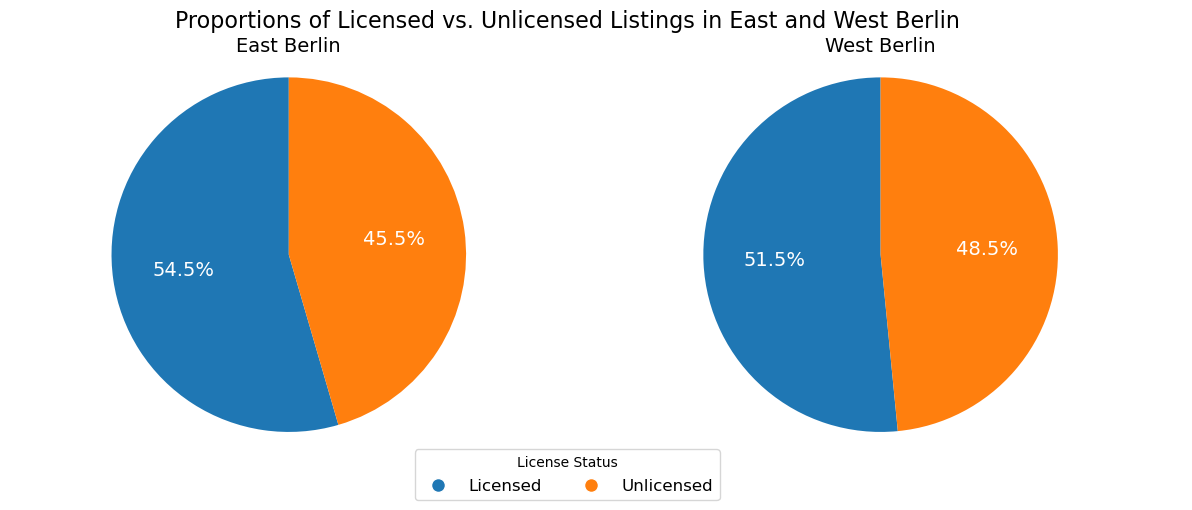

In [40]:
# Filter data to keep only East and West Berlin
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin'])
]

# Group by region and license_status
grouped = df_filtered.groupby(['region', 'license_status']).size().reset_index(name='count')

# Separate data for East and West Berlin
east = grouped[grouped['region'] == 'East Berlin']
west = grouped[grouped['region'] == 'West Berlin']

# Define color palette for license status
license_colors = {
    'Licensed': '#1f77b4',   # Blue
    'Unlicensed': '#ff7f0e'  # Orange
}

# Plot pie charts for East and West Berlin
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# East Berlin pie chart
wedges_east, _, _ = axes[0].pie(
    east['count'],
    labels=east['license_status'],
    autopct='%1.1f%%',
    colors=[license_colors.get(ls, '#D3D3D3') for ls in east['license_status']],
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[0].set_title('East Berlin', fontsize=14)
axes[0].axis('equal')

# West Berlin pie chart
wedges_west, _, _ = axes[1].pie(
    west['count'],
    labels=west['license_status'],
    autopct='%1.1f%%',
    colors=[license_colors.get(ls, '#D3D3D3') for ls in west['license_status']],
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[1].set_title('West Berlin', fontsize=14)
axes[1].axis('equal')

# Add the legend
labels = list(license_colors.keys())
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=license_colors[lt], markersize=10) for lt in labels]

fig.legend(handles, labels, title="License Status", loc='center', fontsize=12, bbox_to_anchor=(0.5, 0.05), ncol=2)

# Overall title and layout
plt.suptitle('Proportions of Licensed vs. Unlicensed Listings in East and West Berlin', fontsize=16)
plt.subplots_adjust(bottom=0.1)

# Save the plot
plt.savefig(data_dir + "Figures/License_Status_Proportions.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [43]:
# Group by host and region, counting the number of observations for each group
collapsed_df = df_idunique.groupby(['host_id', 'region']).size().reset_index(name='num_observations')

# Display the resulting DataFrame
print(collapsed_df)

          host_id       region  num_observations
0          1581.0  West Berlin                 3
1          2217.0  East Berlin                 3
2          2217.0  West Berlin                 4
3          3718.0  East Berlin                 1
4          8890.0  West Berlin                 1
...           ...          ...               ...
9955  666764397.0  West Berlin                 1
9956  666781571.0  West Berlin                 1
9957  667333552.0  West Berlin                 1
9958  667407129.0  East Berlin                 1
9959  667407129.0  West Berlin                 1

[9960 rows x 3 columns]


C:\Users\np37\AppData\Local\Temp\ipykernel_24996\2148787378.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  east_df['num_observations_capped'] = east_df['num_observations'].apply(lambda x: 5 if x > 5 else x)
C:\Users\np37\AppData\Local\Temp\ipykernel_24996\2148787378.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  west_df['num_observations_capped'] = west_df['num_observations'].apply(lambda x: 5 if x > 5 else x)


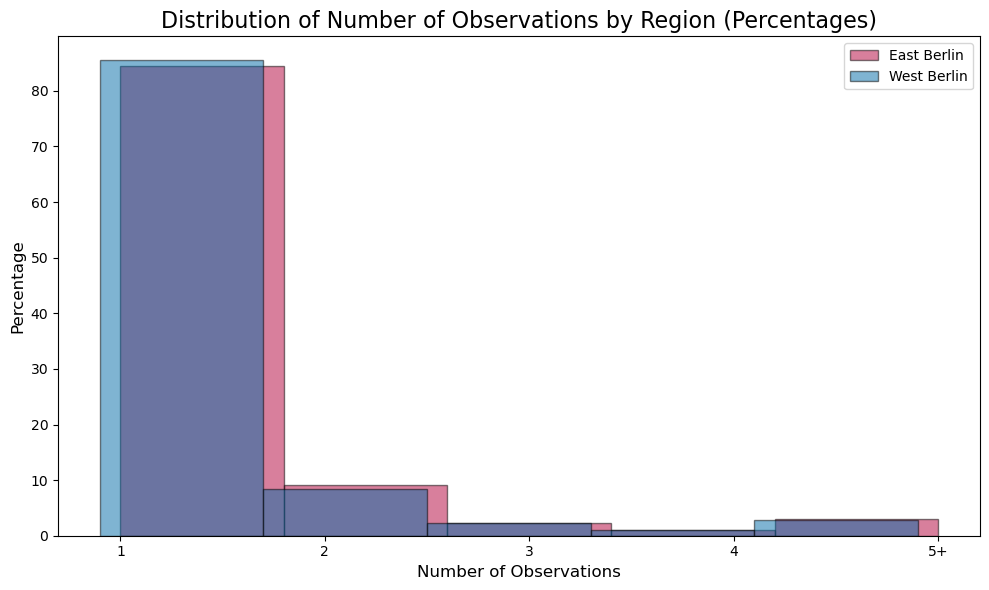

In [70]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Separate the collapsed DataFrame by region
east_df = collapsed_df[collapsed_df['region'] == 'East Berlin']
west_df = collapsed_df[collapsed_df['region'] == 'West Berlin']

# Apply a transformation to cap all values above 5 to 5
east_df['num_observations_capped'] = east_df['num_observations'].apply(lambda x: 5 if x > 5 else x)
west_df['num_observations_capped'] = west_df['num_observations'].apply(lambda x: 5 if x > 5 else x)

# Create the histograms
plt.figure(figsize=(10, 6))

# Plot the East Berlin histogram (red, transparent), with capped values
n_east, bins_east, patches_east = plt.hist(east_df['num_observations_capped'], bins=5, alpha=0.5, label='East Berlin', color='#B2003A', edgecolor='black')

# Plot the West Berlin histogram (blue, less transparent), with capped values and shift it to the right
n_west, bins_west, patches_west = plt.hist(west_df['num_observations_capped'] - 0.1, bins=5, alpha=0.5, label='West Berlin', color='#006BA6', edgecolor='black')

# Convert the histogram counts to percentages
total_east = n_east.sum()
total_west = n_west.sum()

# Normalize the counts to percentages
n_east_percent = (n_east / total_east) * 100
n_west_percent = (n_west / total_west) * 100

# Re-plot the histograms using percentage values
plt.cla()  # Clear the current axes before plotting new histograms
plt.hist(bins_east[:-1], bins=bins_east, weights=n_east_percent, alpha=0.5, label='East Berlin', color='#B2003A', edgecolor='black')
plt.hist(bins_west[:-1], bins=bins_west, weights=n_west_percent, alpha=0.5, label='West Berlin', color='#006BA6', edgecolor='black')

# Add title and labels
plt.title('Distribution of Number of Observations by Region (Percentages)', fontsize=16)
plt.xlabel('Number of Observations', fontsize=12)
plt.ylabel('Percentage', fontsize=12)

# Define a custom formatter for x-ticks to label values above 5 as "5+"
def format_ticks(x, pos):
    if x == 5:
        return '5+'
    return f'{int(x)}'

# Set the custom formatter for x-axis
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_ticks))

# Add a legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


This one doesn't look that interesting really.

Let's try all the samee graphs excluding the places very close to the wall:

## The following looks kind of wrong, I'm making a mistake somewhere

In [77]:
# Dividing sample between close to wall and far from wall:

near_wall = df_idunique[df_idunique["distance_to_wall_m"] <= 10000]
farfrom_wall = df_idunique[df_idunique["distance_to_wall_m"] > 10000]


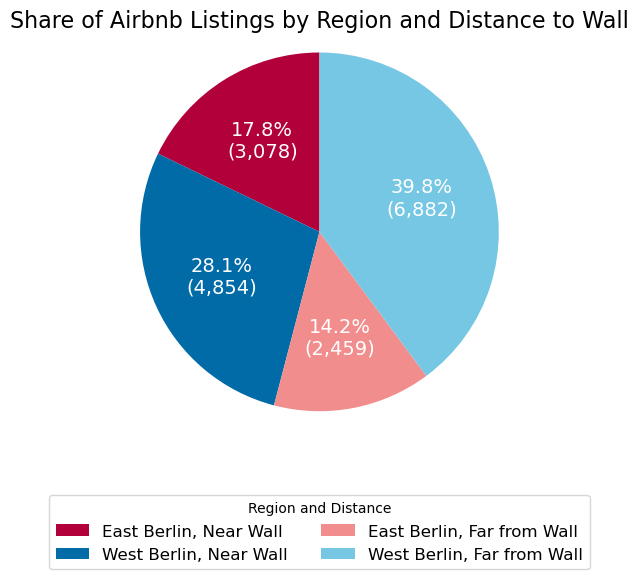

In [86]:
# Filter data to keep only East and West Berlin with non-null boroughs and distance to wall
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin']) &
    df_idunique['borough'].notnull() &
    df_idunique['distance_to_wall_m'].notnull()
]

# Separate the data based on distance to wall (<=1000 for near wall, >1000 for far from wall)
near_wall = df_filtered[df_filtered['distance_to_wall_m'] <= 1000]
farfrom_wall = df_filtered[df_filtered['distance_to_wall_m'] > 1000]

# Group by region and distance category, counting the number of observations
near_wall_counts = near_wall['region'].value_counts()
farfrom_wall_counts = farfrom_wall['region'].value_counts()

# Combine the counts into a single series
combined_counts = pd.concat([near_wall_counts, farfrom_wall_counts])
combined_counts = combined_counts.sort_index()

# Define colors for each group
colors = ['#B2003A', '#006BA6', '#F28D8D', '#76C7E3']  # Dark red for East Near Wall, Blue for West Near Wall, Light red for East Far, Light blue for West Far

# Custom label function
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count:,})'
    return my_autopct

# Define the labels
labels = [
    'East Berlin, Near Wall',
    'West Berlin, Near Wall',
    'East Berlin, Far from Wall',
    'West Berlin, Far from Wall'
]

# Plot pie chart
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    combined_counts,
    autopct=make_autopct(combined_counts),
    colors=colors,
    startangle=90,
    textprops={'color': 'white',  'fontsize': 14},  # Make the text white
    labeldistance=1.1  # Move labels outside the pie chart
)

# Adding a custom legend for the pie chart
labels_for_legend = [
    'East Berlin, Near Wall',
    'West Berlin, Near Wall',
    'East Berlin, Far from Wall',
    'West Berlin, Far from Wall'
]

# Create custom legend with two columns
plt.legend(wedges, labels_for_legend, title="Region and Distance", loc="upper center", fontsize=12, bbox_to_anchor=(0.5, -0.15), ncol=2)

# Customize font size and title
plt.title('Share of Airbnb Listings by Region and Distance to Wall', fontsize=16, color='black')  # Title in black
plt.axis('equal')
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(data_dir + "Figures/Number_listings_by_distance.png", dpi=300)

# Show the plot
plt.show()


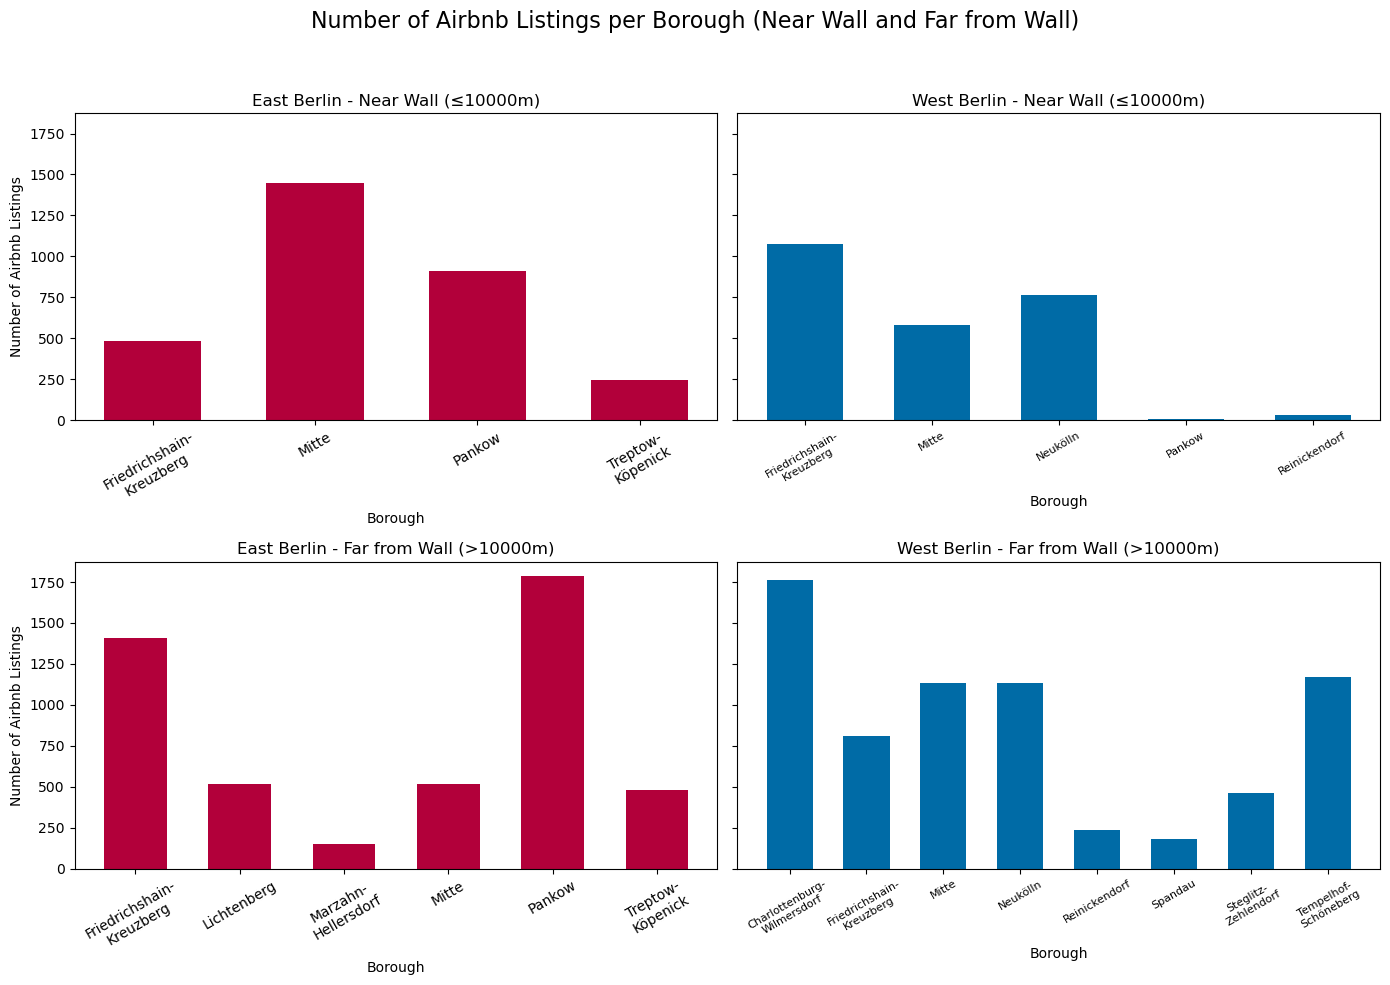

In [87]:
# Filter data to keep only East and West Berlin with non-null boroughs
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin']) &
    df_idunique['borough'].notnull()
]

# Separate into near_wall and farfrom_wall based on the new threshold (10000 meters)
near_wall = df_filtered[df_filtered["distance_to_wall_m"] <= 1000]
farfrom_wall = df_filtered[df_filtered["distance_to_wall_m"] > 1000]

# Group by borough, region, and distance, counting the number of observations
grouped_near_wall = near_wall.groupby(['borough', 'region']).size().reset_index(name='count')
grouped_farfrom_wall = farfrom_wall.groupby(['borough', 'region']).size().reset_index(name='count')

# Separate data for East and West Berlin for near_wall and farfrom_wall
east_near_wall = grouped_near_wall[grouped_near_wall['region'] == 'East Berlin'].copy()
west_near_wall = grouped_near_wall[grouped_near_wall['region'] == 'West Berlin'].copy()
east_farfrom_wall = grouped_farfrom_wall[grouped_farfrom_wall['region'] == 'East Berlin'].copy()
west_farfrom_wall = grouped_farfrom_wall[grouped_farfrom_wall['region'] == 'West Berlin'].copy()

# Format borough labels (keep hyphen and insert newline after it)
east_near_wall['formatted_borough'] = east_near_wall['borough'].apply(lambda x: x.replace('-', '-\n'))
west_near_wall['formatted_borough'] = west_near_wall['borough'].apply(lambda x: x.replace('-', '-\n'))
east_farfrom_wall['formatted_borough'] = east_farfrom_wall['borough'].apply(lambda x: x.replace('-', '-\n'))
west_farfrom_wall['formatted_borough'] = west_farfrom_wall['borough'].apply(lambda x: x.replace('-', '-\n'))

# Custom color palette
cranberry_red = '#B2003A'
economist_blue = '#006BA6'

# Set consistent bar width and x positions
bar_width = 0.6
east_near_x = np.arange(len(east_near_wall))
west_near_x = np.arange(len(west_near_wall))
east_far_x = np.arange(len(east_farfrom_wall))
west_far_x = np.arange(len(west_farfrom_wall))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

# East Berlin near wall subplot
axes[0, 0].bar(east_near_x, east_near_wall['count'], width=bar_width, color=cranberry_red)
axes[0, 0].set_xticks(east_near_x)
axes[0, 0].set_xticklabels(east_near_wall['formatted_borough'], rotation=30, fontsize=10)
axes[0, 0].set_title('East Berlin - Near Wall (≤10000m)')
axes[0, 0].set_xlabel('Borough')
axes[0, 0].set_ylabel('Number of Airbnb Listings')

# West Berlin near wall subplot
axes[0, 1].bar(west_near_x, west_near_wall['count'], width=bar_width, color=economist_blue)
axes[0, 1].set_xticks(west_near_x)
axes[0, 1].set_xticklabels(west_near_wall['formatted_borough'], rotation=30, fontsize=8)
axes[0, 1].set_title('West Berlin - Near Wall (≤10000m)')
axes[0, 1].set_xlabel('Borough')

# East Berlin far from wall subplot
axes[1, 0].bar(east_far_x, east_farfrom_wall['count'], width=bar_width, color=cranberry_red)
axes[1, 0].set_xticks(east_far_x)
axes[1, 0].set_xticklabels(east_farfrom_wall['formatted_borough'], rotation=30, fontsize=10)
axes[1, 0].set_title('East Berlin - Far from Wall (>10000m)')
axes[1, 0].set_xlabel('Borough')
axes[1, 0].set_ylabel('Number of Airbnb Listings')

# West Berlin far from wall subplot
axes[1, 1].bar(west_far_x, west_farfrom_wall['count'], width=bar_width, color=economist_blue)
axes[1, 1].set_xticks(west_far_x)
axes[1, 1].set_xticklabels(west_farfrom_wall['formatted_borough'], rotation=30, fontsize=8)
axes[1, 1].set_title('West Berlin - Far from Wall (>10000m)')
axes[1, 1].set_xlabel('Borough')

# Overall title and layout
plt.suptitle('Number of Airbnb Listings per Borough (Near Wall and Far from Wall)', fontsize=16)

# Adjust layout to minimize space between the subplots and title
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot as a PNG file
plt.savefig(data_dir + "Figures/Number_listings_perborough_bydistance.png", dpi=300)

# Show the plot
plt.show()


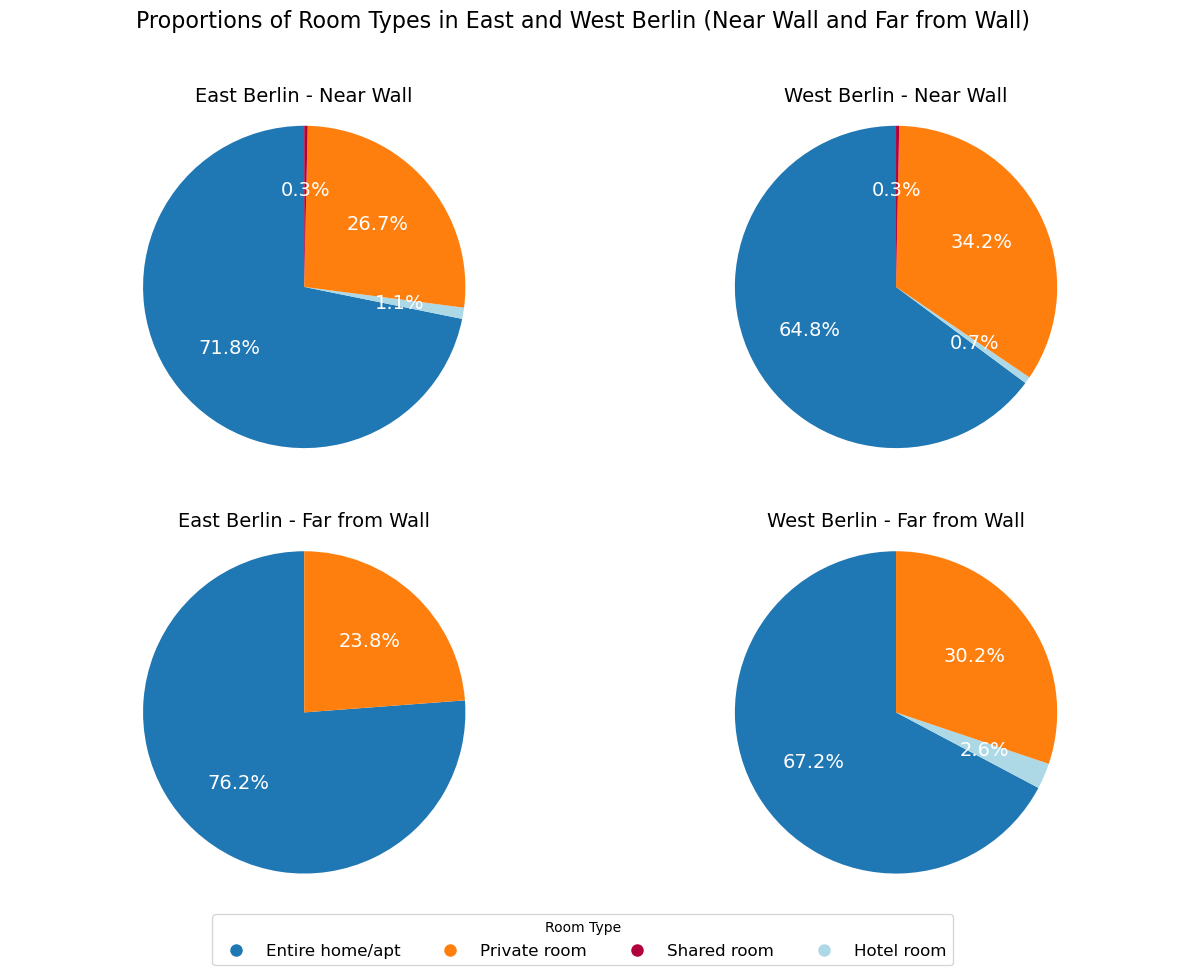

In [ ]:
# Filter data to keep only East and West Berlin with non-null room_type
df_filtered = df_idunique[
    df_idunique['region'].isin(['East Berlin', 'West Berlin']) &
    df_idunique['room_type'].notnull()
]

# Separate into near_wall and farfrom_wall
near_wall = df_filtered[df_filtered["distance_to_wall_m"] <= 10000]
farfrom_wall = df_filtered[df_filtered["distance_to_wall_m"] > 10000]

# Group by region, distance, and room_type, counting the number of observations
grouped_near_wall = near_wall.groupby(['region', 'room_type']).size().reset_index(name='count')
grouped_farfrom_wall = farfrom_wall.groupby(['region', 'room_type']).size().reset_index(name='count')

# Separate data for East and West Berlin for near_wall and farfrom_wall
east_near_wall = grouped_near_wall[grouped_near_wall['region'] == 'East Berlin']
west_near_wall = grouped_near_wall[grouped_near_wall['region'] == 'West Berlin']
east_farfrom_wall = grouped_farfrom_wall[grouped_farfrom_wall['region'] == 'East Berlin']
west_farfrom_wall = grouped_farfrom_wall[grouped_farfrom_wall['region'] == 'West Berlin']

# Use colorblind-friendly colors
room_type_colors = {
    'Entire home/apt': '#1f77b4',  # Blue
    'Private room': '#ff7f0e',     # Orange
    'Shared room': '#B2003A',      # Red 
    'Hotel room': '#ADD8E6'        # Light blue
}

# Plot pie charts for East and West Berlin (near_wall and farfrom_wall)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

# East Berlin near wall pie chart
wedges_east_near, _, _ = axes[0, 0].pie(
    east_near_wall['count'],
    labels=east_near_wall['room_type'],
    autopct='%1.1f%%',  # Directly show percentage
    colors=[room_type_colors.get(rt, '#D3D3D3') for rt in east_near_wall['room_type']],  # Default gray if unknown room_type
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[0, 0].set_title('East Berlin - Near Wall', fontsize=14)
axes[0, 0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# West Berlin near wall pie chart
wedges_west_near, _, _ = axes[0, 1].pie(
    west_near_wall['count'],
    labels=west_near_wall['room_type'],
    autopct='%1.1f%%',  # Directly show percentage
    colors=[room_type_colors.get(rt, '#D3D3D3') for rt in west_near_wall['room_type']],  # Default gray if unknown room_type
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[0, 1].set_title('West Berlin - Near Wall', fontsize=14)
axes[0, 1].axis('equal')

# East Berlin far from wall pie chart
wedges_east_far, _, _ = axes[1, 0].pie(
    east_farfrom_wall['count'],
    labels=east_farfrom_wall['room_type'],
    autopct='%1.1f%%',  # Directly show percentage
    colors=[room_type_colors.get(rt, '#D3D3D3') for rt in east_farfrom_wall['room_type']],  # Default gray if unknown room_type
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[1, 0].set_title('East Berlin - Far from Wall', fontsize=14)
axes[1, 0].axis('equal')

# West Berlin far from wall pie chart
wedges_west_far, _, _ = axes[1, 1].pie(
    west_farfrom_wall['count'],
    labels=west_farfrom_wall['room_type'],
    autopct='%1.1f%%',  # Directly show percentage
    colors=[room_type_colors.get(rt, '#D3D3D3') for rt in west_farfrom_wall['room_type']],  # Default gray if unknown room_type
    startangle=90,
    textprops={'color': 'white', 'fontsize': 14}
)
axes[1, 1].set_title('West Berlin - Far from Wall', fontsize=14)
axes[1, 1].axis('equal')

# Add the legend below the pie charts
labels = list(room_type_colors.keys())
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=room_type_colors[lt], markersize=10) for lt in labels]

# Set the legend location to a more controlled place
fig.legend(handles, labels, title="Room Type", loc='center', fontsize=12, bbox_to_anchor=(0.5, 0.05), ncol=4)

# Overall title and layout
plt.suptitle('Proportions of Room Types in East and West Berlin (10km from wall)', fontsize=16)

# Adjust layout to minimize space between pie charts and legend
plt.subplots_adjust(bottom=0.1)  # Reduced bottom space

# Save the plot as a PNG file
#plt.savefig(data_dir + "Figures/RoomType_Proportions_Four.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()
